In [136]:
from pathlib import Path
import pandas as pd
import json
import pickle
import warnings
import shutil
import re
import hdf5storage

import importlib
import utils.functions as func
importlib.reload(func)
from utils.functions import *

from tqdm import tqdm
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

from applefy_extensions.contrast_curves import ContrastFast
from applefy.statistics import TTest, gaussian_sigma_2_fpf, fpf_2_gaussian_sigma
from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.utils.file_handling import save_as_fits
from applefy.utils.contrast_grid import compute_contrast_from_grid

from fours.utils.data_handling import read_fours_root_dir
from fours.utils.setups import contrast_grid_setup_1
from fours.detection_limits.applefy_wrapper import CADIDataReductionGPU, PCADataReductionGPU
from fours.detection_limits.applefy_wrapper import FourSDataReduction
from fours.models.psf_subtraction import FourS

# Load the Data

In [3]:
frame_rate = 1 / 400  # s
dit_science = 15e-3  # s
dit_psf = 0.5  # s
pixel_size = None  # arcsec
# LambdaD     = 4     #pixels
n_psf = round(dit_psf / dit_science)



sc_img_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy")
sc_img_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy")
psf_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_int_0.5ro_10ws.npy")
psf_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_pred_0.5ro_10ws.npy")


In [4]:
datasets = {
    "int": {
        "psf": psf_int,
        "sci_img": sc_img_int,
        "fwhm": calculate_fwhm(psf_int),
        "dit_psf": dit_psf,  # s of integration time
        "dit_science": dit_science,  # s = 10 phase screens at 0.001s each
    },
    "pred": {
        "psf": psf_pred,
        "sci_img": sc_img_pred,
        "fwhm": calculate_fwhm(psf_pred),
        "dit_psf": dit_psf,  # s of integration time
        "dit_science": dit_science,
    },
}

dataset = datasets['int']

FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 



# Run fake planet experiments for PCA and cADI

In [5]:
contrast_result_dir = "/home/aosimul/noah/results/contrast_grid"
name = "test_grid_merged"
grid = True
device = 'cpu'

path = f"{contrast_result_dir}/{name}" #_{algo_name}"
if os.path.exists(path):
    shutil.rmtree(Path(path))
    print(f"Removed existing directory to avoid overwrites: {path}.")

if not os.path.exists(path):
    os.makedirs(path)

angles = np.linspace(0, 30, np.shape(dataset["sci_img"])[0])  # parang[::10]
angles = np.deg2rad(angles)

contrast_instance = ContrastFast(
    science_sequence=dataset["sci_img"],
    psf_template=dataset["psf"],
    parang_rad=angles,
    psf_fwhm_radius=dataset["fwhm"] / 2,  # Diameter in pixel
    device=device,
    dit_psf_template=dataset["dit_psf"],
    dit_science=dataset["dit_science"],  # integration time
    checkpoint_dir=Path(path),
)


Removed existing directory to avoid overwrites: /home/aosimul/noah/results/contrast_grid/test_grid_merged.


## Design fake planet experiments

In [7]:
flux_ratios_mag = np.linspace(4, 17, 5)
flux_ratios = mag2flux_ratio(flux_ratios_mag)

contrast_instance.design_fake_planet_experiments(
    flux_ratios=flux_ratios,
    num_planets=2,
    overwrite=True)

Overwriting existing config files.


## Run fake planet experiments for cADI

In [8]:
cadi_algorithm_function = CADIDataReductionGPU(0)
contrast_instance.run_fake_planet_experiments(
    algorithm_function=cadi_algorithm_function,
    num_parallel=1)

Running fake planet experiments...

100%|██████████| 111/111 [00:23<00:00,  4.72it/s]

[DONE]


In [9]:
contrast_instance.results_dict.keys()

dict_keys(['cADI'])

## Run fake planet experiments for PCA

In [10]:
pca_numbers = np.concatenate(
    [np.arange(0, 30, 2)[1:],
     np.arange(30, 100, 10),
     np.arange(100, 200, 20),
     np.arange(200, 550, 50)])

In [11]:
work_dir = contrast_instance.scratch_dir / Path("tensorboard_pca")


In [12]:
pca_algorithm_function = PCADataReductionGPU(
        approx_svd= 200,
        pca_numbers=pca_numbers,
        device="cpu",
        work_dir=work_dir,
        #special_name="test",
        verbose=False)

In [13]:
old_results = contrast_instance.results_dict
contrast_instance.run_fake_planet_experiments(
    algorithm_function=pca_algorithm_function,
    num_parallel=1)
contrast_instance.results_dict.update(old_results)

Running fake planet experiments...

100%|██████████| 111/111 [06:36<00:00,  3.57s/it]

[DONE]


# Compute Contrast Grids for PCA and cADI

In [14]:
# Use apertures pixel values
photometry_mode_planet = AperturePhotometryMode(
    "F",
    psf_fwhm_radius= dataset["fwhm"]/2,
    search_area=0.5)

photometry_mode_noise = AperturePhotometryMode(
    "P",
    psf_fwhm_radius= dataset["fwhm"]/2)

In [15]:
contrast_instance.prepare_contrast_results(
    photometry_mode_planet=photometry_mode_planet,
    photometry_mode_noise=photometry_mode_noise)

In [16]:
statistical_test = TTest()

In [17]:
contrast_grids = contrast_instance.compute_contrast_grids(
    statistical_test=statistical_test,
    num_cores=45,
    num_rot_iter=10,
    #compute_snr_grid=True,
    confidence_level_fpf = gaussian_sigma_2_fpf(5),
    safety_margin=2.5,
    pixel_scale=None)

Computing contrast grid for _PCA_002_components
...........Computing contrast grid with multiprocessing:
............................................[DONE]
Computing contrast grid for _PCA_004_components
............Computing contrast grid with multiprocessing:
...........................................[DONE]
Computing contrast grid for _PCA_006_components
...........Computing contrast grid with multiprocessing:
............................................[DONE]
Computing contrast grid for _PCA_008_components
...........Computing contrast grid with multiprocessing:
............................................[DONE]
Computing contrast grid for _PCA_010_components
..........Computing contrast grid with multiprocessing:
.............................................[DONE]
Computing contrast grid for _PCA_012_components
.........Computing contrast grid with multiprocessing:
..............................................[DONE]
Computing contrast grid for _PCA_014_components
.............Com

Save merged PCA residuals.

In [18]:
# all_residuals = []

# for tmp_method_name, tmp_result in contrast_instance.contrast_results.items():
#     if not tmp_method_name.startswith("stacked_05_PCA"):
#         continue
#     all_residuals.append(tmp_result.residuals)

In [19]:
# all_residuals = np.array(all_residuals)
# save_as_fits(all_residuals, experiment_root_dir / Path("residuals_pca.fits"))

# Plot and Analysis

## Get overall best results with PCA

In [ ]:
# baseline_grids = deepcopy(contrast_grids[1])
# del baseline_grids["cADI"]

# all_grids = np.array(
#     [tmp_grid.values
#      for tmp_grid in baseline_grids.values()])

# over_all_best = deepcopy(contrast_grids[1]["_PCA_002_components"])
# over_all_best.iloc[:, :] = np.max(all_grids, axis=0)
# over_all_best.index = flux_ratio2mag(over_all_best.index)

In [115]:
baseline_grids = deepcopy(contrast_grids[1])
del baseline_grids["cADI"]

all_grids = np.array(
    [fpf_2_gaussian_sigma(tmp_grid.values)
     for tmp_grid in baseline_grids.values()])

# Best values
# all_grids = (fpf_2_gaussian_sigma(all_grids))
best_values = np.max(all_grids, axis=0)

# Which grid produced the best value
best_idx = np.argmax(all_grids, axis=0)

# Map indices to PCA numbers
pca_numbers = np.array([
    int(key.split("_")[2])
    for key in baseline_grids.keys()
])

best_pca = pca_numbers[best_idx]

# Store as DataFrames
best_value_df = deepcopy(next(iter(baseline_grids.values())))
best_value_df.iloc[:, :] = best_values
best_value_df.index = flux_ratio2mag(best_value_df.index)

best_pca_df = deepcopy(best_value_df)
best_pca_df.iloc[:, :] = best_pca
best_pca_df.index = flux_ratio2mag(best_pca_df.index)

In [117]:
best_value_df

separation [FWHM],1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
flux_ratio,,,,,,,,,,,
4.00,2.873384,4.242242,6.629070,8.267346,8.858686,9.685852,10.465369,12.181690,13.608626,14.098324,14.670008
7.25,3.404561,6.472621,8.755626,9.069165,10.245483,11.049169,11.815888,12.716070,14.027993,15.590762,15.727138
10.50,2.167779,4.539920,7.707767,9.114948,9.712384,10.136714,10.586145,11.001685,11.762390,12.240776,12.124336
13.75,1.521619,0.649474,1.877226,2.617764,4.252888,4.436543,3.395505,2.848074,2.881111,2.665409,3.488029
17.00,0.984984,0.351259,0.045040,0.246931,-0.010991,0.956146,1.078215,1.255302,0.594175,1.530626,2.059110


In [119]:
def plot_overall_best(grid, pca = False):

    fig = plt.figure(figsize=(8, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs0.update(wspace=0.0, hspace=0.2)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec = gs0[0],
        wspace=0.05, width_ratios=[1, 0.03])

    # All axis we need
    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])
    if pca == False:
        #grid = grid.map(fpf_2_gaussian_sigma)
        title = 'Overall Best Performance'
    else:
        title = 'Overall Best - PCA component'

    # Plot the contrast grid
    plot_contrast_grid(
        contrast_grid_axis=contrast_ax,
        colorbar_axis=colorbar_ax,
        contrast_grid=grid, 
        cmap = 'YlGn' if pca == True else "YlGnBu",
        vmax = np.max(grid) if pca == True else 2,
        )

    contrast_ax.set_ylabel(
        "Contrast - $c = f_p / f_*$ - [mag]", size=14)
    contrast_ax.set_xlabel(
        r"Separation [FWHM]", size=14)
    contrast_ax.set_title(
        "Contrast Grid: " + title,
        fontsize=16,
        fontweight="bold",
        y=1.03)

    contrast_ax.tick_params(
        axis='both',
        which='major',
        labelsize=12)

    # Save the figure
    fig.patch.set_facecolor('white')

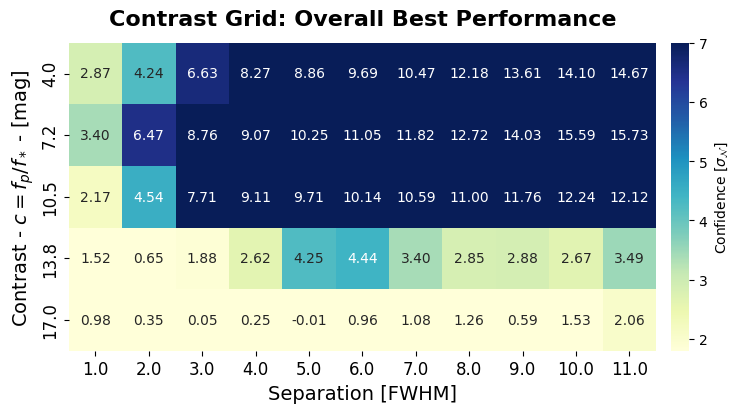

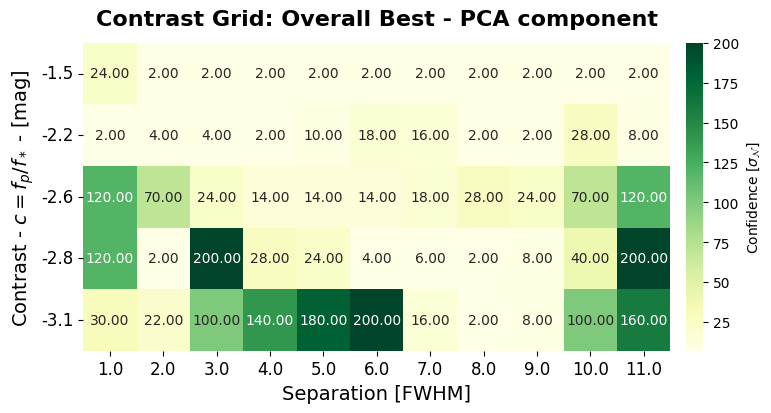

In [120]:
plot_overall_best(best_value_df)
plt.show()
plot_overall_best(best_pca_df, pca = True)

In [137]:
def plot_contrast_curves(
    contrast_curves, 
    lim_mag_y,
    curves_output_path = None, 
    dataset_name = 'test',
    contrast_errors = None, 
    lim_x = None, 
    title = None,
    cmap = "magma",
    alpha = 0.7,
    ):

    # compute the overall best contrast curve
    PADI_values = contrast_curves.loc[:, ~contrast_curves.columns.str.contains("cADI", regex=True)]
    if len(PADI_values.columns) > 0:
        overall_best = np.min(PADI_values.values, axis=1)

        # get the error bars of the the overall best contrast curve
        best_idx = np.argmin(PADI_values.values, axis=1)

        # Find one color for each number of PCA components used
        color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
        colors = [color_map(int(i)) for i in np.round(np.linspace(0, 220, len(PADI_values.columns)))]

    if isinstance(contrast_curves.index, pd.MultiIndex):
        separations_arcsec = contrast_curves.index.get_level_values(0)
        separations_FWHM = contrast_curves.index.get_level_values(1)

        x = separations_FWHM        # bottom axis
        x_top = separations_arcsec  # top axis
        multi_index = True
    else:
        x = contrast_curves.index
        multi_index = False

    # 1.) Create Plot Layout
    fig = plt.figure(constrained_layout=False, figsize=(12, 8))
    gs0 = fig.add_gridspec(1, 1)
    axis_contrast_curves = fig.add_subplot(gs0[0, 0])


    # ---------------------- Create the Plot --------------------
    i = 0 # color picker
    for tmp_model in contrast_curves.columns:
        
        if 'cADI'.lower() in tmp_model.lower():
            num_components = 'cADI'
            color = 'red'
        else:
            num_components = int(tmp_model[5:8])
            color = colors[i]
            i+=1
        tmp_flux_ratios = contrast_curves.reset_index(
            level=0)[tmp_model].values


        axis_contrast_curves.plot(
            x,
            tmp_flux_ratios,
            color = color,
            alpha = alpha,
            label=num_components)

        if contrast_errors is not None:
            tmp_errors = contrast_errors.reset_index(
                level=0)[tmp_model].values
            
            axis_contrast_curves.fill_between(
                x,
                tmp_flux_ratios + tmp_errors,
                tmp_flux_ratios - tmp_errors,
                color = color,
                alpha=alpha/2)
            
            if len(PADI_values.columns) > 0:
                best_contrast_errors = contrast_errors.values[np.arange(len(best_idx)), best_idx]

                axis_contrast_curves.fill_between(
                    x,
                    overall_best + best_contrast_errors,
                    overall_best - best_contrast_errors,
                    color = 'blue',
                    alpha=alpha/2)

    axis_contrast_curves.set_yscale("log")
    # ------------ Plot the overall best -------------------------
    if len(PADI_values.columns) > 0:
        axis_contrast_curves.plot(
            x,
            overall_best,
            color = "blue",
            lw=3,
            ls="--",
            label="Best")

        best_pca = [
            int(re.search(r"PCA_(\d+)", col).group(1))
            for col in PADI_values.columns[best_idx]
        ]
        #save the overall best
        result = pd.DataFrame(
            {
                #"separation_FWHM": x,
                "best_contrast": overall_best,
                "best_PCA": best_pca,
            },
            index=PADI_values.index,
        )

    # ------------- Double axis and limits -----------------------
    if lim_x:
        lim_x = lim_x
    else:
        lim_x = (np.min(x) - 0.01, np.max(x) + 0.01)


    axis_contrast_curves_mag = axis_contrast_curves.twinx()
    axis_contrast_curves_mag.plot(
        x,
        flux_ratio2mag(tmp_flux_ratios),
        alpha=0.)
    axis_contrast_curves_mag.invert_yaxis()


    axis_contrast_curves.grid(which='both')
    axis_contrast_curves_mag.set_ylim(*lim_mag_y)
    axis_contrast_curves.set_ylim(
        (mag2flux_ratio(lim_mag_y[0])),
        (mag2flux_ratio(lim_mag_y[1])))

    axis_contrast_curves.set_xlim(*lim_x)
    axis_contrast_curves_mag.set_xlim(*lim_x)


    if multi_index:
        fwhm_to_arcsec = interpolate.interp1d(
            separations_FWHM,
            separations_arcsec,
            fill_value="extrapolate"
        )

        axis_contrast_curves_arcsec = axis_contrast_curves.twiny()
        axis_contrast_curves_arcsec.plot(
            separations_arcsec,
            tmp_flux_ratios,
            alpha=0,
        )

        axis_contrast_curves_arcsec.set_xlim(
            *fwhm_to_arcsec(lim_x)
        )
    # ----------- Labels and fontsizes --------------------------
    
        axis_contrast_curves_arcsec.set_xlabel(
            "Separation [arcsec]", size=16
        )
        axis_contrast_curves_arcsec.tick_params(
            axis='both', which='major', labelsize=14)
    
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )
    else:
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )

    axis_contrast_curves.set_ylabel(
        r"Planet-to-star flux ratio", size=16)
    axis_contrast_curves_mag.set_ylabel(
        r"$\Delta$ Magnitude", size=16)

    axis_contrast_curves.tick_params(
        axis='both', which='major', labelsize=14)

    axis_contrast_curves_mag.tick_params(
        axis='both', which='major', labelsize=14)

    # # ----------- Labels and fontsizes --------------------------
    if title:
        set_title = title
    else:
        set_title = r"$5 \sigma_{\mathcal{N}}$ Contrast Curves"
    axis_contrast_curves_mag.set_title(
        set_title,
        fontsize=18, fontweight="bold", y=1.05)

    # --------------------------- Legend -----------------------
    handles, labels = axis_contrast_curves.\
        get_legend_handles_labels()

    leg1 = fig.legend(handles, labels,
                    bbox_to_anchor=(0.12, -0.1),
                    fontsize=14,
                    title="# PCA components",
                    loc='lower left', ncol=8)

    _=plt.setp(leg1.get_title(),fontsize=14)
    #plt.savefig(f"{(curves_output_path)}/Contrast_Curves_{dataset_name}.png", pad_inches=0.15)
    return result   


/tmp/ipykernel_3364530/824040035.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl


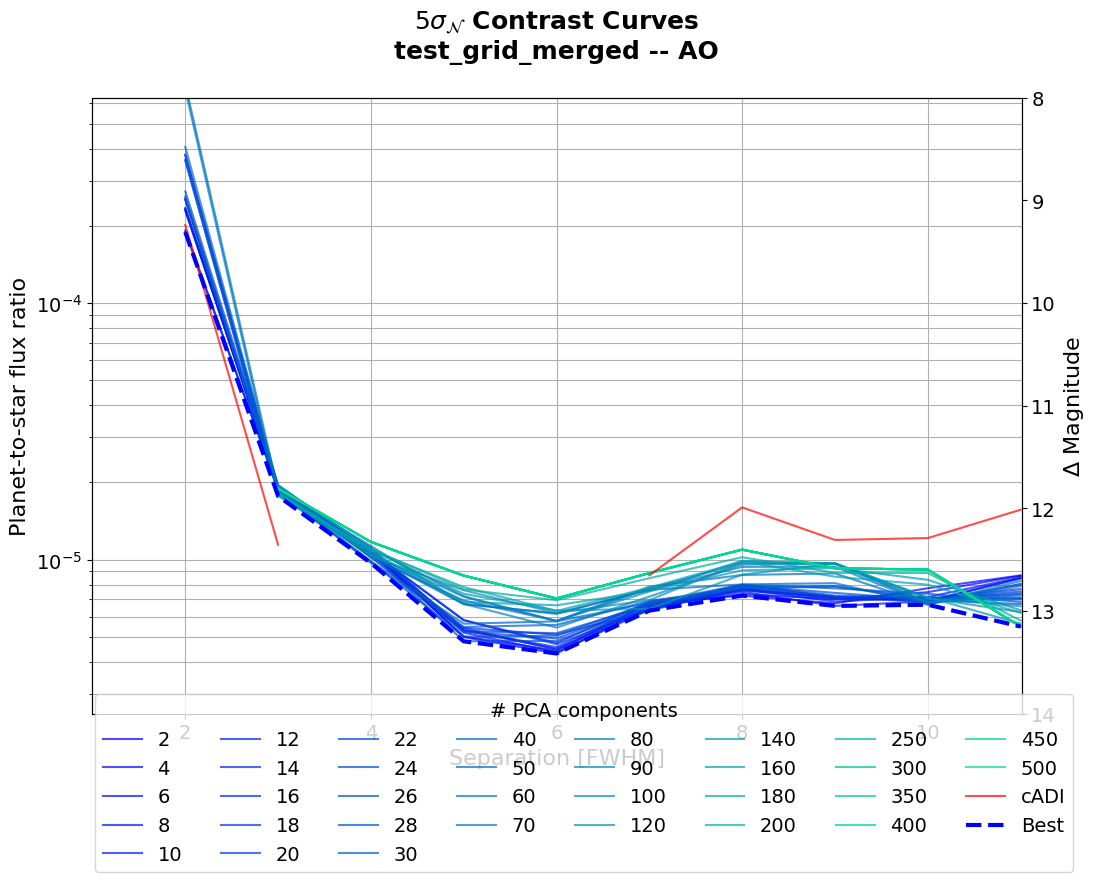

In [138]:
rangey      = (14, 8)

result = plot_contrast_curves(contrast_grids[0], rangey, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- AO"))
#plt.savefig(f'{name}.png', bbox_inches="tight", pad_inches=0.15)
result.to_hdf(
    "/home/aosimul/noah/src/pipeline_ADI/results/contrast/overall_best.h5",
    key='test',
    mode="a"
)

In [140]:
df = pd.read_hdf("/home/aosimul/noah/src/pipeline_ADI/results/contrast/overall_best.h5")
df

,best_contrast,best_PCA
separation [FWHM],,
1.0,inf,2
2.0,0.000189,12
3.0,0.000018,70
4.0,0.000010,28
5.0,0.000005,24
6.0,0.000004,4
7.0,0.000006,18
8.0,0.000007,2
9.0,0.000007,8


In [70]:
def save_grid_animation(contrast_grids, curves_output_path, dataset_name):

    keys = list(contrast_grids.keys())

    fig = plt.figure(figsize=(7, 4))

    gs0 = fig.add_gridspec(1, 1)
    gs1 = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=gs0[0],
        wspace=0.05,
        width_ratios=[1, 0.03]
    )

    contrast_ax = fig.add_subplot(gs1[0])
    colorbar_ax = fig.add_subplot(gs1[1])


    def update(i):
        contrast_ax.clear()
        colorbar_ax.clear()

        key = keys[i]

        grid = contrast_grids[key].copy()

        # convert FPF to sigma
        grid = grid.map(fpf_2_gaussian_sigma)

        # convert flux ratio to magnitude
        grid.index = flux_ratio2mag(grid.index)
    
        algo_name = 'CADI' if key =='cADI' else 'PCAD'
        
        plot_contrast_grid(
            contrast_grid_axis=contrast_ax,
            colorbar_axis=colorbar_ax,
            contrast_grid=grid,
            cmap = 'YlOrRd' if algo_name == 'CADI' else "YlGnBu"
        )

        contrast_ax.set_ylabel("Contrast - $c=f_p/f_*$ [mag]", fontsize=14)
        contrast_ax.set_xlabel("Separation [FWHM]", fontsize=14)

        contrast_ax.set_title(
            f"{dataset_name.replace("_", " ")}: {key.replace("_", " ")}",
            fontsize=16,
            fontweight="bold"
        )

        contrast_ax.tick_params(labelsize=12)
        plt.subplots_adjust(bottom=0.2)
        plt.close()

    ani = FuncAnimation(
        fig,
        update,
        frames=len(keys),
        interval=500
    )

    ani.save(f"{(curves_output_path)}/GRID_{dataset_name}.gif", writer=PillowWriter(fps=1))

In [109]:
curves_output_path = '/home/aosimul/noah/results/animations/GRID'

save_grid_animation(contrast_grids[1], curves_output_path, 'test')